In [17]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
%pip install matplotlib
%pip install seaborn

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:

stock_symbol = "NVDA"
start_date = "2022-01-01"
end_date = "2024-01-01"

data = yf.download(stock_symbol, start=start_date, end=end_date)


data.columns = data.columns.get_level_values(0)


data = data.reset_index()

[*********************100%***********************]  1 of 1 completed


In [ ]:

print(data.info())
print(data.describe())

<class 'pandas.DataFrame'>
RangeIndex: 501 entries, 0 to 500
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype        
---  ------  --------------  -----        
 0   Date    501 non-null    datetime64[s]
 1   Close   501 non-null    float64      
 2   High    501 non-null    float64      
 3   Low     501 non-null    float64      
 4   Open    501 non-null    float64      
 5   Volume  501 non-null    int64        
dtypes: datetime64[s](1), float64(4), int64(1)
memory usage: 23.6 KB
None
Price                 Date       Close        High         Low        Open  \
count                  501  501.000000  501.000000  501.000000  501.000000   
mean   2022-12-31 15:37:00   27.521352   28.033036   26.963679   27.499502   
min    2022-01-03 00:00:00   11.212296   11.719632   10.798838   10.956631   
25%    2022-07-05 00:00:00   16.964706   17.378364   16.617467   16.961711   
50%    2022-12-30 00:00:00   23.864817   24.281791   23.339339   23.739984   
75%    2023-07-03 00:

In [ ]:

data["Movement"] = np.where(data["Close"] >= data["Open"], "Up", "Down")

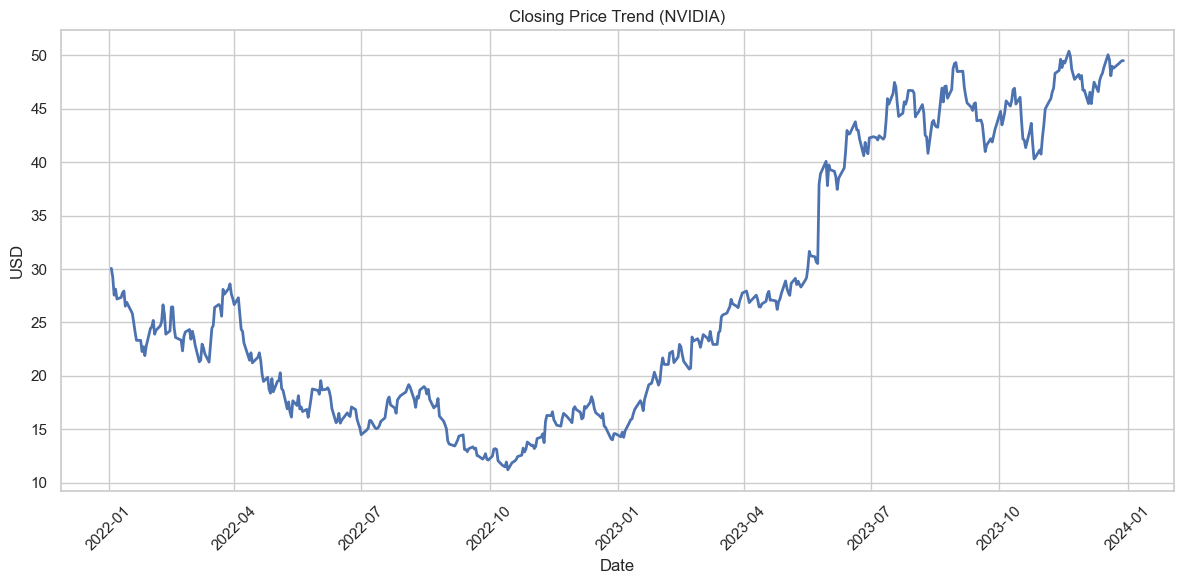

In [ ]:

plt.figure(figsize=(12, 6))
plt.plot(data["Date"], data["Close"], linewidth=2)
plt.title("Closing Price Trend (NVIDIA)")
plt.xlabel("Date")
plt.ylabel("USD")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

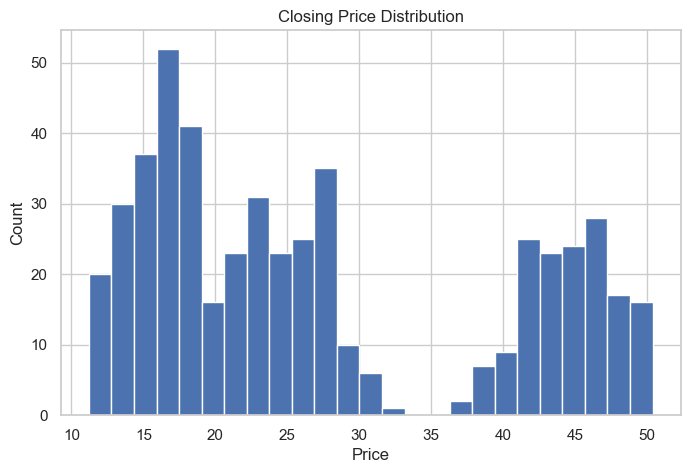

In [ ]:

plt.figure(figsize=(8, 5))
plt.hist(data["Close"], bins=25)
plt.title("Closing Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

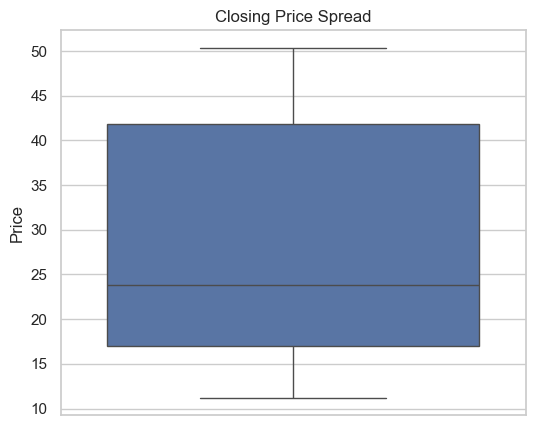

In [ ]:

plt.figure(figsize=(6, 5))
sns.boxplot(y=data["Close"])
plt.title("Closing Price Spread")
plt.ylabel("Price")
plt.show()

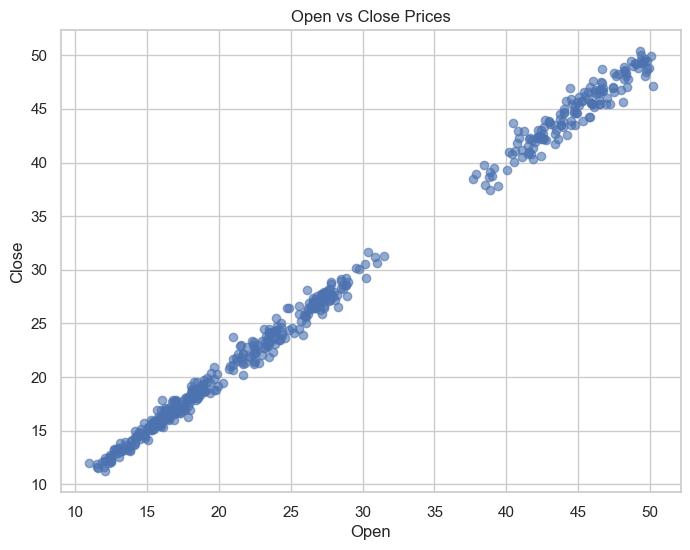

In [ ]:

plt.figure(figsize=(8, 6))
plt.scatter(data["Open"], data["Close"], alpha=0.6)
plt.title("Open vs Close Prices")
plt.xlabel("Open")
plt.ylabel("Close")
plt.show()

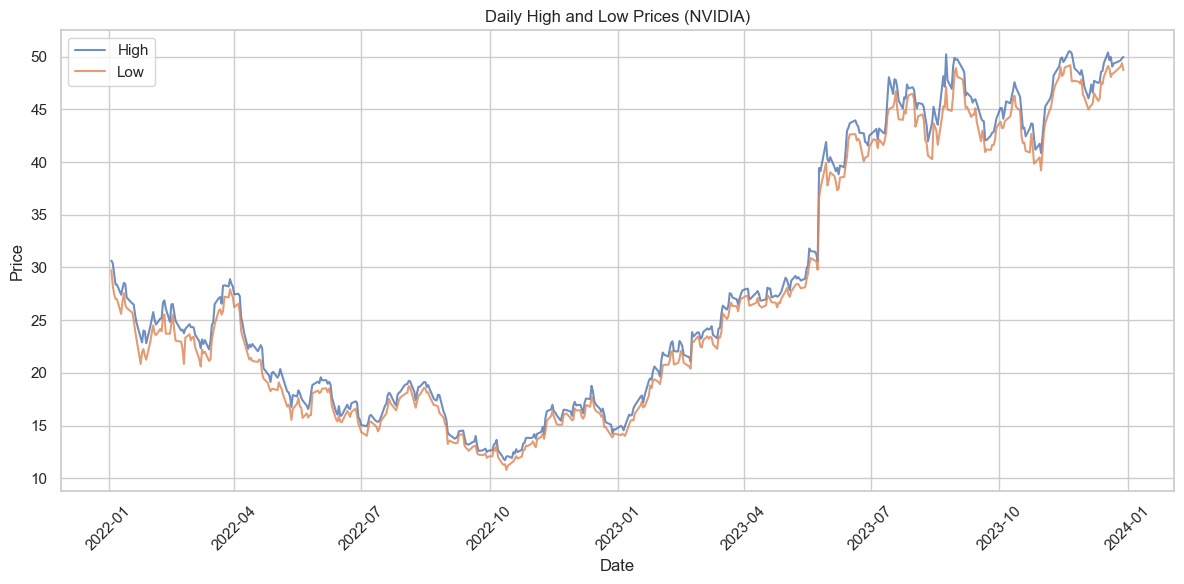

In [ ]:

plt.figure(figsize=(12, 6))
plt.plot(data["Date"], data["High"], label="High", alpha=0.8)
plt.plot(data["Date"], data["Low"], label="Low", alpha=0.8)
plt.title("Daily High and Low Prices (NVIDIA)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

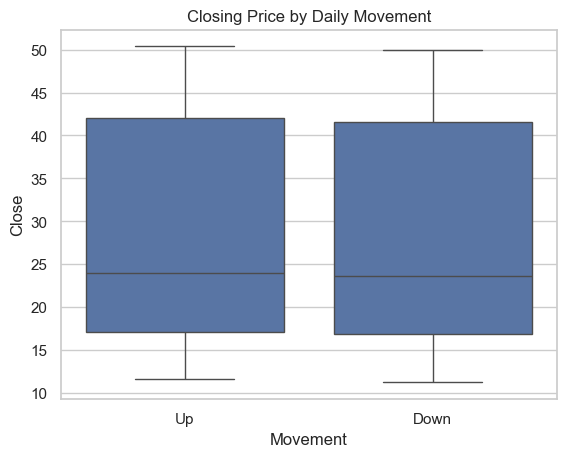

In [ ]:

sns.boxplot(data=data, x="Movement", y="Close")
plt.title("Closing Price by Daily Movement")
plt.show()

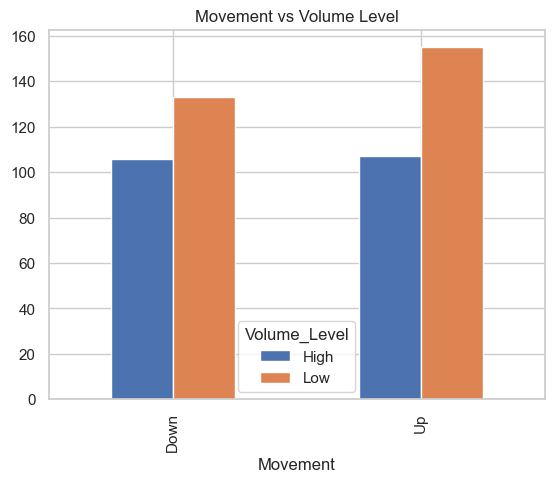

In [ ]:

avg_volume = data["Volume"].mean()
data["Volume_Level"] = np.where(data["Volume"] > avg_volume, "High", "Low")

pd.crosstab(data["Movement"], data["Volume_Level"]).plot(kind="bar")
plt.title("Movement vs Volume Level")
plt.show()

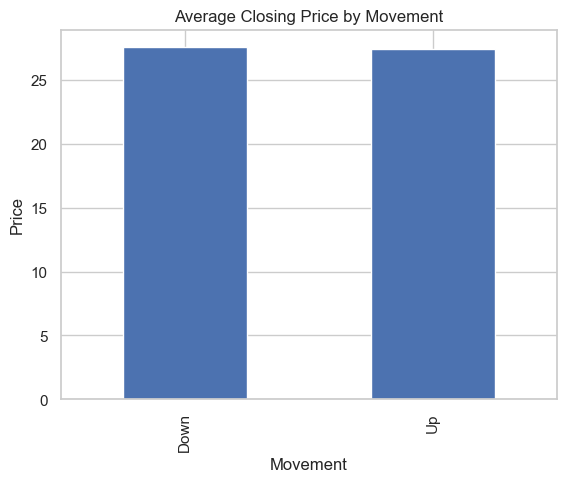

In [ ]:

data.groupby("Movement")["Close"].mean().plot(kind="bar")
plt.title("Average Closing Price by Movement")
plt.ylabel("Price")
plt.show()

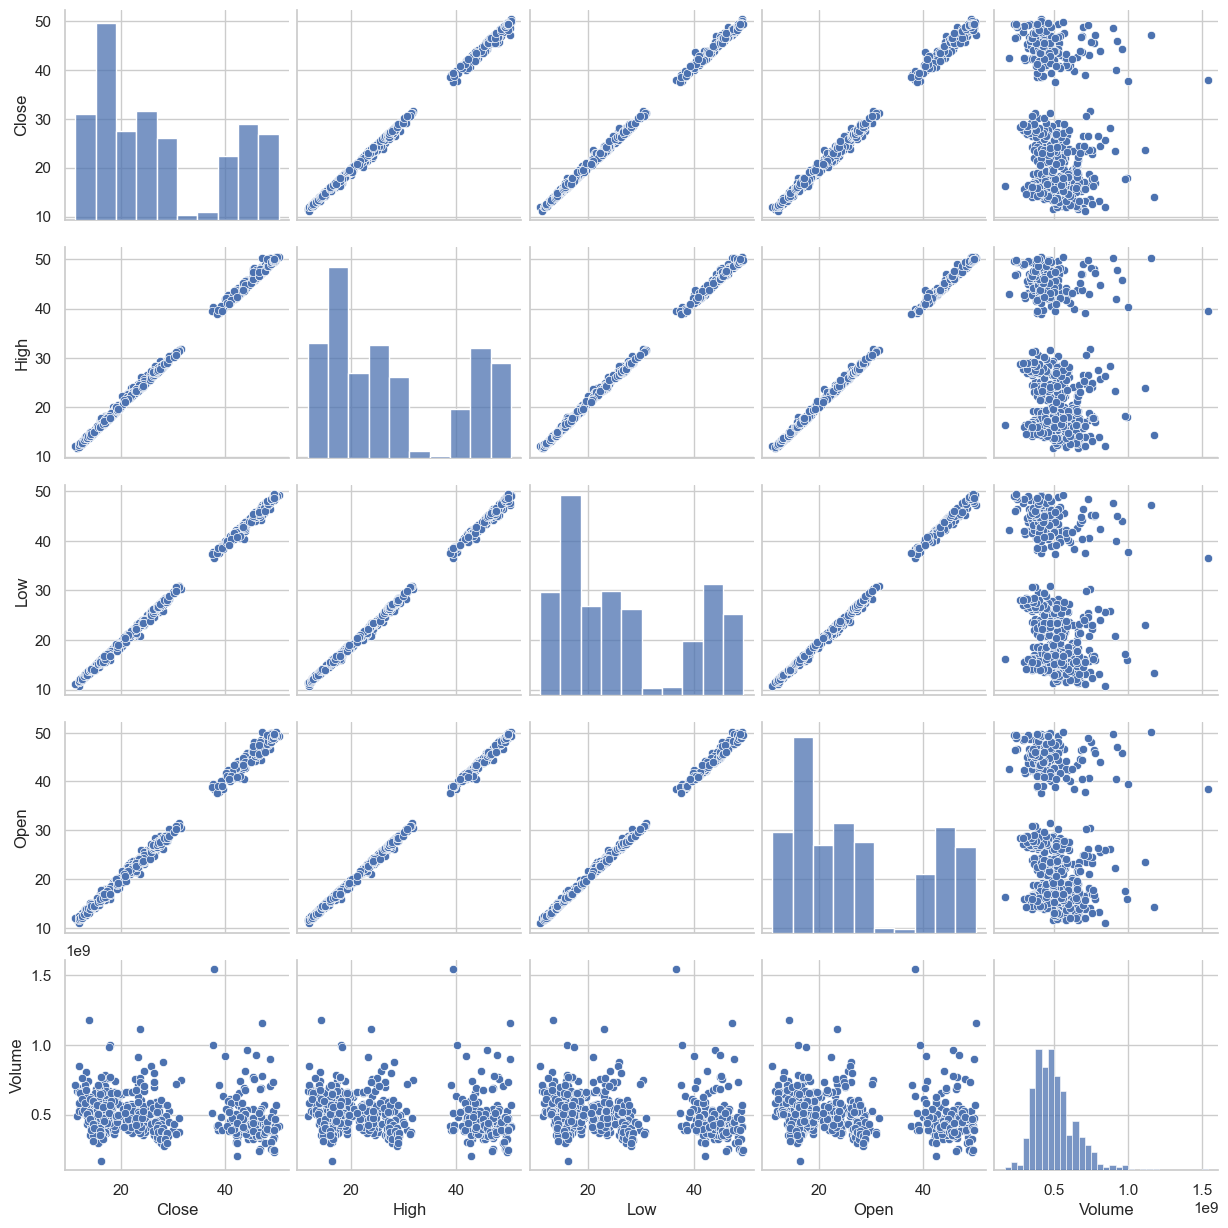

In [ ]:

sns.pairplot(data.select_dtypes(include=np.number))
plt.show()